## Functional Utility Evaluation
This notebook evaluates the synthetic clinical dataset generated by analysing its performance across across five different Machine Learning models. Assessing how the dataset performs for its intended task, each model is trained to classify and predict the patient's risk level of having opioid toxicity.

The models selected include Logistic Regression, Random Forest, XGBoost Classifier, Support Vector Classifier, and TabPFN representing the most common models used for risk classification in medical domains. Each model is evaluated using a stratified 10-fold cross-validation and assessed through the following metrics: AUROC, F1, precision and recall. 


In [1]:
#Define imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
import tabpfn_client
from tabpfn_client import TabPFNClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTENC
import os
from dotenv import load_dotenv
from sklearn.utils.class_weight import compute_sample_weight

#### Data Cleaning and Preprocessing

The data cleaning and preprocessing phase includes reading the synthetic dataset, dropping non-feature columns such as patient ID and free text summaries and encoding all categorical features including the target variable. The process additionally integrates the setup of a 10 fold cross-validation, applied to the full dataset. All records are setup to participate in both training and evaluation cycle, while preserving class distribution.

In [2]:
#Load dataset
df = pd.read_csv('MV_dataset.csv')
display(df)

,patient_ID,TWC-000,TWC-001,TWC-002,TWC-003,TWC-004,HAL-000,HAL-001,HAL-002,HAL-003,...,MED-OPD-001,MED-OPD-002,MED-OPD-002-1,MED-OPD-003,ALC-000,HST-OPX-000,INF-000,AGE-000,Patient_Summary,Outcome
0,ID_654,Yes,New symptom,At unpredictable times,Trembling,Legs or feet,No,not_asked,not_asked,not_asked,...,No,No,not_asked,No,No,No,No,Below 65,The patient is reporting: Twitching (Symptom E...,High
1,ID_233,No,not_asked,not_asked,not_asked,not_asked,No,not_asked,not_asked,not_asked,...,No,No,not_asked,Yes,No,No,No,Below 65,The patient is reporting: Dizziness (Symptom E...,Medium
2,ID_135,No,not_asked,not_asked,not_asked,not_asked,No,not_asked,not_asked,not_asked,...,No,Yes,In the last 7-14 days,No,No,No,No,Below 65,The patient is reporting: Sedation (Symptom Ev...,High
3,ID_209,No,not_asked,not_asked,not_asked,not_asked,No,not_asked,not_asked,not_asked,...,No,Yes,In the last 7-14 days,No,No,No,No,Below 65,The patient is reporting: Drowsiness (Symptom ...,Low
4,ID_830,Yes,Same as usual,After physical activity,Trembling,Face,No,not_asked,not_asked,not_asked,...,No,Yes,In the last 7-14 days,Yes,No,No,No,Below 65,The patient is reporting: Twitching (Symptom E...,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,ID_515,No,not_asked,not_asked,not_asked,not_asked,No,not_asked,not_asked,not_asked,...,No,Yes,In the last 7-14 days,Yes,No,No,No,Below 65,The patient is reporting: Sedation (Symptom Ev...,High
346,ID_35,No,not_asked,not_asked,not_asked,not_asked,No,not_asked,not_asked,not_asked,...,No,No,not_asked,Yes,Yes,No,No,65 or Above,The patient is reporting: Sedation (Symptom Ev...,High
347,ID_429,Yes,New symptom,After physical activity,Sudden jerks,Legs or feet,No,not_asked,not_asked,not_asked,...,No,No,not_asked,Yes,No,Yes,No,Below 65,The patient is reporting: Twitching (Symptom E...,High
348,ID_553,No,not_asked,not_asked,not_asked,not_asked,No,not_asked,not_asked,not_asked,...,No,No,not_asked,Yes,Yes,No,No,65 or Above,The patient is reporting: Slurred Speech (Symp...,High


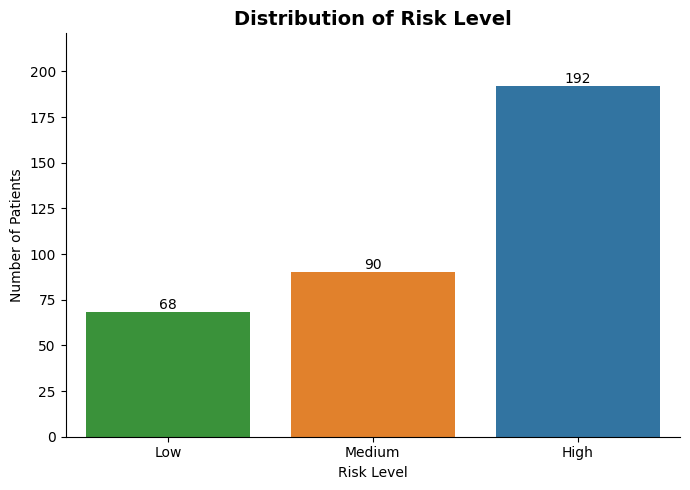

In [3]:
#Define figure
fig, ax = plt.subplots(figsize=(7, 5))

#Define the order of the risk levels, from low to high
order = ['Low', 'Medium', 'High']

sns.countplot(data=df, x='Outcome', hue='Outcome',
              order=order, legend=False, ax=ax)

#Add count at the top of the bars for each risk category
for container in ax.containers:
    ax.bar_label(container)

#Set plot details
ax.set_title('Distribution of Risk Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Risk Level')
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, df['Outcome'].value_counts().max() * 1.15)
sns.despine()

plt.tight_layout()
plt.show()

This visualization indicates the class imbalance of the synthetic dataset, with high risk cases representing a significant proportion of the patient records.

In [4]:
#Drop non-feature columns
df.drop(columns=["patient_ID", "Patient_Summary"], inplace=True)
display(df)

#Drop Outcome column from X variable
X = df.drop(columns=["Outcome"])

#Define outcome as y variable
y = df["Outcome"]

,TWC-000,TWC-001,TWC-002,TWC-003,TWC-004,HAL-000,HAL-001,HAL-002,HAL-003,DRW-000,...,MED-REC-000,MED-OPD-001,MED-OPD-002,MED-OPD-002-1,MED-OPD-003,ALC-000,HST-OPX-000,INF-000,AGE-000,Outcome
0,Yes,New symptom,At unpredictable times,Trembling,Legs or feet,No,not_asked,not_asked,not_asked,Yes,...,No,No,No,not_asked,No,No,No,No,Below 65,High
1,No,not_asked,not_asked,not_asked,not_asked,No,not_asked,not_asked,not_asked,No,...,No,No,No,not_asked,Yes,No,No,No,Below 65,Medium
2,No,not_asked,not_asked,not_asked,not_asked,No,not_asked,not_asked,not_asked,No,...,No,No,Yes,In the last 7-14 days,No,No,No,No,Below 65,High
3,No,not_asked,not_asked,not_asked,not_asked,No,not_asked,not_asked,not_asked,Yes,...,No,No,Yes,In the last 7-14 days,No,No,No,No,Below 65,Low
4,Yes,Same as usual,After physical activity,Trembling,Face,No,not_asked,not_asked,not_asked,Yes,...,No,No,Yes,In the last 7-14 days,Yes,No,No,No,Below 65,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,No,not_asked,not_asked,not_asked,not_asked,No,not_asked,not_asked,not_asked,No,...,No,No,Yes,In the last 7-14 days,Yes,No,No,No,Below 65,High
346,No,not_asked,not_asked,not_asked,not_asked,No,not_asked,not_asked,not_asked,No,...,No,No,No,not_asked,Yes,Yes,No,No,65 or Above,High
347,Yes,New symptom,After physical activity,Sudden jerks,Legs or feet,No,not_asked,not_asked,not_asked,No,...,Yes,No,No,not_asked,Yes,No,Yes,No,Below 65,High
348,No,not_asked,not_asked,not_asked,not_asked,No,not_asked,not_asked,not_asked,No,...,No,No,No,not_asked,Yes,Yes,No,No,65 or Above,High


In [5]:
#Encode all categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(X)

#Encode target feature
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

#Define cross-validation split
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

#### Baseline Analysis
The models are first evaluated without applied balancing strategies, as means of establishing a baseline result.

##### Logistic Regression Model

Logistic Regression
AUROC: 0.8415900490774746
F1: 0.6562124433226026
Recall: 0.6577109440267336
Precision: 0.6754438982070561


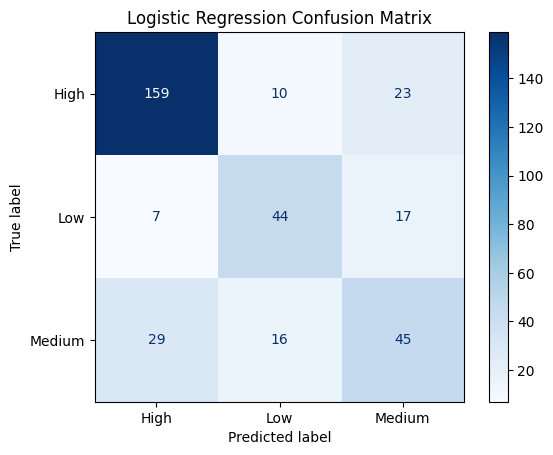

In [ ]:
#Store performance scores
LR_auroc_scores = []
LR_f1_scores = []
LR_precision_scores = []
LR_recall_scores = []

#Store all predictions from the 10 folds
LR_full_y_test = []
LR_full_y_pred = []

#Split data into training and testing data
for train_data, test_data in cv.split(X_encoded, y_encoded):
    X_train = X_encoded[train_data]
    X_test = X_encoded[test_data]

    y_train = y_encoded[train_data]
    y_test = y_encoded[test_data]

    #Define logistic regression model
    model = LogisticRegression(max_iter=5000, random_state=42)

    #Train model
    model.fit(X_train, y_train)

    #Compute predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    #Calculate performance metrics
    LR_auroc_scores.append(roc_auc_score(y_test, y_prob, multi_class='ovr'))
    LR_f1_scores.append(f1_score(y_test, y_pred, average='macro'))
    LR_precision_scores.append(precision_score(y_test, y_pred, average='macro'))
    LR_recall_scores.append(recall_score(y_test, y_pred, average='macro'))

    #Append all predictions across the 10 folds
    LR_full_y_test.extend(y_test)
    LR_full_y_pred.extend(y_pred)

#Print scores
print("Logistic Regression")
print("AUROC:", np.mean(LR_auroc_scores))
print("F1:", np.mean(LR_f1_scores))
print("Recall:", np.mean(LR_recall_scores))
print("Precision:", np.mean(LR_precision_scores))

#Plot confusion matrix of the last fold
log_matrix = confusion_matrix(LR_full_y_test, LR_full_y_pred)
plot = ConfusionMatrixDisplay(confusion_matrix=log_matrix, display_labels=le_target.classes_)
plot.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.savefig('LG-confusion.pdf', bbox_inches='tight')
plt.show()

The Logistic Regression Model performs with an AUROC score of 0.842, showing the model can reasonably discriminate across risk levels. The F1 score, however, reveals a lower performance with a score of 0.656 (recall=0.658 and precision=0.675). These scores suggest the model has a moderate performance, with difficulties remaining in correctly separating the 3 risk levels. Across the risk classes, 67.5% of predictions were correct and the model was able to correctly identify 65.8% of the actual instances across each risk class.

The confusion matrix reveals in more detail the predictions of the Logistic Regression Model against true labels. Across high risk patient records, the model shows a strong ability to identify the correct risk level, with over 80% of patient records being labelled correctly. Across the low risk label, the model was able to correctly identify approximately 65% of the true low risk patient records. In terms of the medium class, the model had the worst performance, correctly predicting only half of the true medium cases, while showing a high bias towards the high risk level. This result suggest similarities between medium and high risk patients, with boundaries that may be harder to discriminate. 


#### Random Forest Classifier Model

Random Forest
AUROC: 0.8410050505194399
F1: 0.6751647677102284
Recall: 0.6632080200501254
Precision: 0.736121625840296


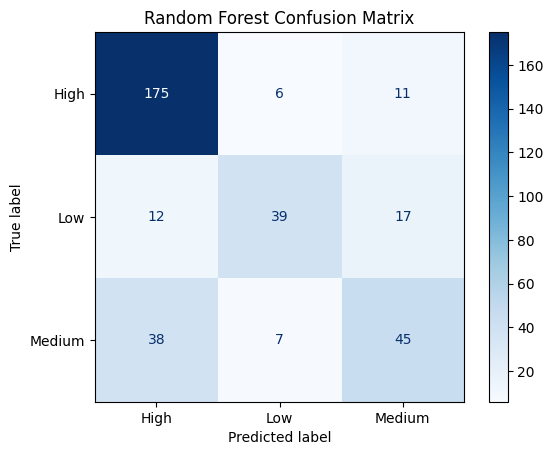

In [7]:
#Store performance scores
RF_auroc_scores = []
RF_f1_scores = []
RF_precision_scores = []
RF_recall_scores = []

#Store all predictions from the 10 folds
RF_full_y_test = []
RF_full_y_pred = []


#Split data into training and testing data
for train_data, test_data in cv.split(X_encoded, y_encoded):
    X_train = X_encoded[train_data]
    X_test = X_encoded[test_data]

    y_train = y_encoded[train_data]
    y_test = y_encoded[test_data]


    #Define Random Forest Classifier model
    model = RandomForestClassifier(random_state=42)

    #Train model
    model.fit(X_train, y_train)

    #Compute predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    #Calculate performance metrics
    RF_auroc_scores.append(roc_auc_score(y_test, y_prob, multi_class='ovr'))
    RF_f1_scores.append(f1_score(y_test, y_pred, average='macro'))
    RF_precision_scores.append(precision_score(y_test, y_pred, average='macro'))
    RF_recall_scores.append(recall_score(y_test, y_pred, average='macro'))

    #Append all predictions across the 10 folds
    RF_full_y_test.extend(y_test)
    RF_full_y_pred.extend(y_pred)

#Print scores
print("Random Forest")
print("AUROC:", np.mean(RF_auroc_scores))
print("F1:", np.mean(RF_f1_scores))
print("Recall:", np.mean(RF_recall_scores))
print("Precision:", np.mean(RF_precision_scores))


#Plot confusion matrix
rf_matrix = confusion_matrix(RF_full_y_test, RF_full_y_pred)
plot = ConfusionMatrixDisplay(confusion_matrix=rf_matrix, display_labels=le_target.classes_)
plot.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.savefig('RF-confusion.pdf', bbox_inches='tight')
plt.show()

The Random Forest Classifier reveals an AUROC score of 0.841, similar to the Logistic Regression Model. This indicates a defensible performance. However, the model's performance drops when evaluated against precision and recall. The F1 score reveals a performance of 0.675, with a recall of 0.663. This suggests that across the three risk levels defined as the outcome, the model can correctly identify 66.3% out of the total actual instances. The precision score reveals that 73.6% of the model's predictions across the risk classes were actually correct. While these scores remain moderate, they are an improvement compared to the performance of the Logistic Regression Model.

The confusion matrix, further provides insights on these trends. Similar to patterns observed in the previous model, the Random Forest Classifier shows a strong performance across high risk label. Over 90% of true high risk patient scenarios were predicted correctly. In comparison, low risk predictions reveal more variability, with only 57% of low risk true labels being correctly identified. Across the medium risk cases, the model shows a strong bias towards the high risk level, with the number of misclassified high risk cases being similar to the number of medium risk predicted cases. These results show the influence of an imbalanced dataset and potential similarities across trends within medium and high risk patient scenarios.


#### XGBoost Classifier Model

XGBoost Classifier
AUROC: 0.8508115910486923
F1: 0.6599099057666665
Recall: 0.6639766081871346
Precision: 0.6783487536428713


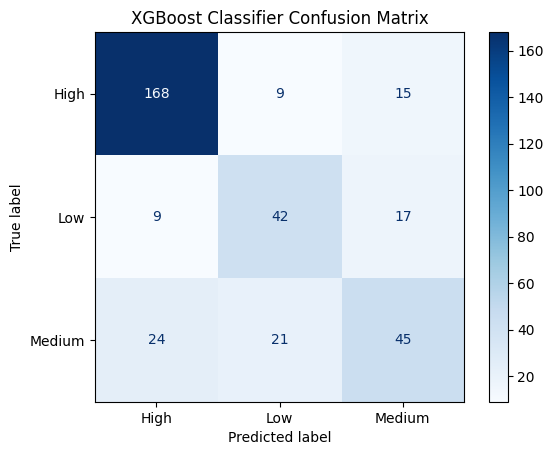

In [8]:
#Store performance scores
XGB_auroc_scores = []
XGB_f1_scores = []
XGB_precision_scores = []
XGB_recall_scores = []

#Store all predictions from the 10 folds
XGB_full_y_test = []
XGB_full_y_pred = []

#Split data into training and testing data
for train_data, test_data in cv.split(X_encoded, y_encoded):
    X_train = X_encoded[train_data]
    X_test = X_encoded[test_data]

    y_train = y_encoded[train_data]
    y_test = y_encoded[test_data]

    #Define XGBoost Classifier model
    model = XGBClassifier(eval_metric='mlogloss', random_state=42, verbosity=0)

    #Train model
    model.fit(X_train, y_train)

    #Compute predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    #Calculate performance metrics
    XGB_auroc_scores.append(roc_auc_score(y_test, y_prob, multi_class='ovr'))
    XGB_f1_scores.append(f1_score(y_test, y_pred, average='macro'))
    XGB_precision_scores.append(precision_score(y_test, y_pred, average='macro'))
    XGB_recall_scores.append(recall_score(y_test, y_pred, average='macro'))

    #Append all predictions across the 10 folds
    XGB_full_y_test.extend(y_test)
    XGB_full_y_pred.extend(y_pred)

#Print scores
print("XGBoost Classifier")
print("AUROC:", np.mean(XGB_auroc_scores))
print("F1:", np.mean(XGB_f1_scores))
print("Recall:", np.mean(XGB_recall_scores))
print("Precision:", np.mean(XGB_precision_scores))

#Plot confusion matrix
xgb_matrix = confusion_matrix(XGB_full_y_test, XGB_full_y_pred)
plot = ConfusionMatrixDisplay(confusion_matrix=xgb_matrix,display_labels=le_target.classes_)
plot.plot(cmap="Blues")
plt.title("XGBoost Classifier Confusion Matrix")
plt.savefig('XGB-confusion.pdf', bbox_inches='tight')
plt.show()

The XGBoost Classifier reveals a similar performance to the previous models, with an AUROC score of 0.851. This suggests the model can discriminate across risk level 85% of the time. Following the patterns revealed across the first models, the XGBoost Classifier's performance lowers when assessed against precision and recall, with an F1 score of 0.660. The model's recall indicates that across the three risk levels, the model can identify 66.4% of the actual instances. In regards to precision, 67.8% of the model's predictions were actually correct.

The confusion matrix reveals more details in terms of the model's performance across the three risk levels. With a strong performance across high risk cases, the model correctly predicted over 87% of the high outcomes. Performance drops for low risk labels, with the model correctly predicting only 62% of the true labels, being biased towards medium cases. Predictions of medium risk cases show a high number of false negatives, as the model misclassified half.

#### Support Vector Classifier Model

Support Vector Classifier
AUROC: 0.7988152054592293
F1: 0.5319722268381307
Recall: 0.5166889445836814
Precision: 0.7218423986340754


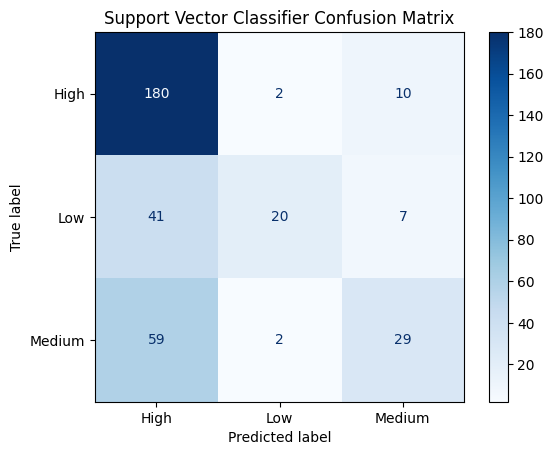

In [9]:
#Store performance scores
SVM_auroc_scores = []
SVM_f1_scores = []
SVM_precision_scores = []
SVM_recall_scores = []

#Store all predictions from the 10 folds
SVM_full_y_test = []
SVM_full_y_pred = []

#Split data into training and testing data
for train_data, test_data in cv.split(X_encoded, y_encoded):
    X_train = X_encoded[train_data]
    X_test = X_encoded[test_data]

    y_train = y_encoded[train_data]
    y_test = y_encoded[test_data]

    #Scale data
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    #Define Support Vector Classifier model
    model = SVC(probability=True,random_state=42)

    #Train model
    model.fit(X_train_scaled, y_train)

    #Compute predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)

    #Calculate performance metrics
    SVM_auroc_scores.append(roc_auc_score(y_test, y_prob, multi_class='ovr'))
    SVM_f1_scores.append(f1_score(y_test, y_pred, average='macro'))
    SVM_precision_scores.append(precision_score(y_test, y_pred, average='macro'))
    SVM_recall_scores.append(recall_score(y_test, y_pred, average='macro'))

    #Append all predictions across the 10 folds
    SVM_full_y_test.extend(y_test)
    SVM_full_y_pred.extend(y_pred)

#Print scores
print("Support Vector Classifier")
print("AUROC:", np.mean(SVM_auroc_scores))
print("F1:", np.mean(SVM_f1_scores))
print("Recall:", np.mean(SVM_recall_scores))
print("Precision:", np.mean(SVM_precision_scores))

#Plot confusion matrix
svm_matrix = confusion_matrix(SVM_full_y_test, SVM_full_y_pred)
plot = ConfusionMatrixDisplay(confusion_matrix=svm_matrix,display_labels=le_target.classes_)
plot.plot(cmap="Blues")
plt.title("Support Vector Classifier Confusion Matrix")
plt.savefig('SVM-confusion.pdf', bbox_inches='tight')
plt.show()

The Support Vector Machine demonstrates the lowest AUROC score across the models, correctly discriminating across classes approximately 80% of the time. As with the previously evaluated models, scores across precision and recall drop significantly compared to AUROC. The Support Vector Classifier has an F1 of 0.532, with a recall of 0.517 which is the lowest scores identified across all models. This suggests that the model can identify a little over half of the actual instances. In contrast, the model's precision shows a higher score, where 72.2% of the model's predictions across each risk was correct.  

The confusion matrix shows strong performance across high risk labels, with around 93% of predict labels being true high risk cases. Across low and medium risk, the model's performance is lower due to misclassification. A strong bias toward high risk cases is shown, explained by the model's data imbalance. 

##### 5.TabPFN Classifier

Found existing access token, reusing it for authentication.

00:00 Fitting... \

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


...

00:00 Fitting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!
TabPFNClassifier
AUROC: 0.8730335733918182
F1: 0.6616274186985683
Recall: 0.65838485101643
Precision: 0.6984935301582899


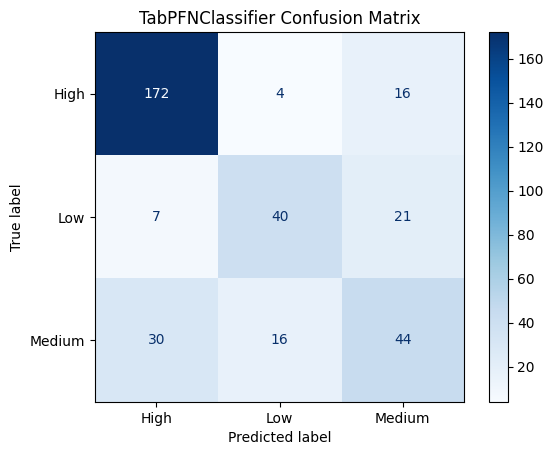

In [10]:
#Load API Token
load_dotenv()
os.environ["TABPFN_API_KEY"] = os.getenv("TABPFN_API_KEY")
tabpfn_client.init()

#Store performance scores
TPFN_auroc_scores = []
TPFN_f1_scores = []
TPFN_precision_scores = []
TPFN_recall_scores = []

#Store all predictions from the 10 folds
TPFN_full_y_test = []
TPFN_full_y_pred = []

#Split data into training and testing data
for train_data, test_data in cv.split(X_encoded, y_encoded):
    X_train = X_encoded[train_data]
    X_test = X_encoded[test_data]

    y_train = y_encoded[train_data]
    y_test = y_encoded[test_data]

    #Define TabPFNClassifier
    model = TabPFNClassifier(random_state=42)
    model.fit(X_train, y_train)

    #Compute predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    #Calculate performance metrics
    TPFN_auroc_scores.append(roc_auc_score(y_test, y_prob, multi_class='ovr'))
    TPFN_f1_scores.append(f1_score(y_test, y_pred, average='macro'))
    TPFN_precision_scores.append(precision_score(y_test, y_pred, average='macro'))
    TPFN_recall_scores.append(recall_score(y_test, y_pred, average='macro'))

  #Append all predictions across the 10 folds
    TPFN_full_y_test.extend(y_test)
    TPFN_full_y_pred.extend(y_pred)

#Print scores
print("TabPFNClassifier")
print("AUROC:", np.mean(TPFN_auroc_scores))
print("F1:", np.mean(TPFN_f1_scores))
print("Recall:", np.mean(TPFN_recall_scores))
print("Precision:", np.mean(TPFN_precision_scores))

#Plot confusion matrix
tabpfn_matrix = confusion_matrix(TPFN_full_y_test, TPFN_full_y_pred)
plot = ConfusionMatrixDisplay(confusion_matrix=tabpfn_matrix,display_labels=le_target.classes_)
plot.plot(cmap="Blues")
plt.title("TabPFNClassifier Confusion Matrix")
plt.savefig('TPFN-confusion.pdf', bbox_inches='tight')
plt.show()

The TabPFNClassifier shows the strongest AUROC score of 0.873 which means the model can discriminate across risk levels 87% of the time. The score lowers for precision and recall, with an F1 score of 0.662. In terms of recall, the model correctly identified 65.8% of actual instances across the three risk classes. The precision score reveals that almost 69.8% of the model's predictions across the different risk levels were actually correct. 

The trends reflected by the confusion matrix are similar to insights identified across the other four models. Across high risks labels, the model identified approximately 90% of them correctly. However, the performance drops for low risk labels, with the model correctly identifying only 60% of them, with many records being misclassified as medium risk. As seen in the previously evaluated models, performance across medium risk labels is the lowest, where the model identified a little under half of the correct labels.


In [11]:
#Overall baseline results
baseline_results = pd.DataFrame([
    {'Model Baseline': 'Logistic Regression', 'AUROC': np.mean(LR_auroc_scores), 'F1': np.mean(LR_f1_scores), 'Precision': np.mean(LR_precision_scores), 'Recall': np.mean(LR_recall_scores)},
    {'Model Baseline': 'Random Forest', 'AUROC': np.mean(RF_auroc_scores), 'F1': np.mean(RF_f1_scores), 'Precision': np.mean(RF_precision_scores), 'Recall': np.mean(RF_recall_scores)},
    {'Model Baseline': 'XGBoost', 'AUROC': np.mean(XGB_auroc_scores), 'F1': np.mean(XGB_f1_scores), 'Precision': np.mean(XGB_precision_scores), 'Recall': np.mean(XGB_recall_scores)},
    {'Model Baseline': 'SVC', 'AUROC': np.mean(SVM_auroc_scores), 'F1': np.mean(SVM_f1_scores), 'Precision': np.mean(SVM_precision_scores), 'Recall': np.mean(SVM_recall_scores)},
    {'Model Baseline': 'TabPFN', 'AUROC': np.mean(TPFN_auroc_scores), 'F1': np.mean(TPFN_f1_scores), 'Precision': np.mean(TPFN_precision_scores), 'Recall': np.mean(TPFN_recall_scores)},
])

display(baseline_results)

,Model Baseline,AUROC,F1,Precision,Recall
0,Logistic Regression,0.841590,0.656212,0.675444,0.657711
1,Random Forest,0.841005,0.675165,0.736122,0.663208
2,XGBoost,0.850812,0.659910,0.678349,0.663977
3,SVC,0.798815,0.531972,0.721842,0.516689
4,TabPFN,0.873034,0.661627,0.698494,0.658385


#### Balanced Models Analysis
The following section evaluates the models by implementing two balancing techniques, class weighting supported as an algorithm-based method, and SMOTE-NC defined as an oversampling approach suitable for categorical and numerical data. 

The class weights dataset balancing approach is applied only to Logistic Regression, Random Forest Classifier, XGBoost Classifier, and Support Vector Machine Classifier. TabPFN does not inherently support class weight parameters in its implementation. 

##### 1. Weighted Models Analysis

In [12]:
#Store overall scores
overall_results_weighted = []

#Define weighted models
weighted_models = [
    ('Logistic Regression', LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced')),
    ('Random Forest', RandomForestClassifier(random_state=42, class_weight='balanced')),
    ('SVC', SVC(probability=True, random_state=42, class_weight='balanced')),
    ('XGBoost', XGBClassifier(eval_metric='mlogloss', random_state=42, verbosity=0))
]

#Iterate through models to apply weighting
for name, model in weighted_models:
    #Store performance scores
    auroc_scores = []
    f1_scores = []
    precision_scores = []
    recall_scores = []

    #Store all predictions from the 10 folds
    full_y_test = []
    full_y_pred = []

    #Split data into training and testing data
    for train_data, test_data in cv.split(X_encoded, y_encoded):
        X_train = X_encoded[train_data]
        X_test = X_encoded[test_data]

        y_train = y_encoded[train_data]
        y_test = y_encoded[test_data]

        #Scale features for SVC
        if name == 'SVC':
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test  = scaler.transform(X_test)
        
        #Apply sample weights to XGBoost
        if name == 'XGBoost':
            sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
            model = XGBClassifier(random_state=42)
            model.fit(X_train, y_train, sample_weight=sample_weights)

        else:
        #Train all models
            model.fit(X_train, y_train)

        #Compute predictions
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

        #Calculate performance metrics
        auroc_scores.append(roc_auc_score(y_test, y_prob, multi_class='ovr'))
        f1_scores.append(f1_score(y_test, y_pred, average='macro'))
        precision_scores.append(precision_score(y_test, y_pred, average='macro'))
        recall_scores.append(recall_score(y_test, y_pred, average='macro'))

        #Append all predictions across the 10 folds
        full_y_test.extend(y_test)
        full_y_pred.extend(y_pred)

    overall_results_weighted.append({
            'Model Weighted': name,
            'AUROC': np.mean(auroc_scores),
            'F1': np.mean(f1_scores),
            'Precision': np.mean(precision_scores),
            'Recall': np.mean(recall_scores),
        })

display(pd.DataFrame(overall_results_weighted))

,Model Weighted,AUROC,F1,Precision,Recall
0,Logistic Regression,0.838318,0.669526,0.683265,0.679389
1,Random Forest,0.826289,0.647209,0.682977,0.640776
2,SVC,0.795907,0.614239,0.647139,0.606731
3,XGBoost,0.846206,0.670304,0.681793,0.679747


The implementation of class weights had minimal influence on the performance of the four models. In terms of Logistic Regression, the weighted model's performance shows a drop in the AUROC score, but a noticeable improvement for per-class metrics, with recall increasing  from 0.658 to 0.679. 

On the Random Forest's performance, this balancing strategy lead to a slight decrease across all metrics, suggesting that the baseline performance with a natural distribution performs better for this model. The XGBoost Classifier follows a pattern similar to Logistic Regression, indicating a small drop in the AUROC score, but slight improvements are seen across all per-class metrics. 

Lastly, class weights show the biggest influence on the Support Vector Classifier. While no substantial changes are seen in the AUROC score, the F1 and recall score improve substantially, increasing by approximately 0.08. 

Overall, this balancing strategy does not result in consistent performance improvements, as weighted models such as Random Forest show a lower performance than the baseline model. 

##### 2. SMOTE-NC Models Analysis

In [13]:
#Identify all categorical columns
categorical = []
for x, column in enumerate(X.columns):
    if X[column].dtype == 'object':
        categorical.append(x)

#Configure SMOTE-NC
smote_nc = SMOTENC(categorical_features=categorical, random_state=42)

#Store all SMOTE-NC results
overall_results_smote_nc = []

#Define models
smote_nc_models = [
    ('Logistic Regression', LogisticRegression(max_iter=5000, random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('SVC', SVC(probability=True, random_state=42)),
    ('XGBoost', XGBClassifier(eval_metric='mlogloss', random_state=42, verbosity=0)),
    ('TabPFN', TabPFNClassifier(random_state=42))
]

#Iterate through models to apply SMOTE-NC
for name, model in smote_nc_models:
    #Store performance scores
    auroc_scores = []
    f1_scores = []
    precision_scores = []
    recall_scores = []

    #Store all predictions from the 10 folds
    full_y_test = []
    full_y_pred = []

    #Split data into training and testing data
    for train_data, test_data in cv.split(X, y_encoded):

        #Define raw feature train and test
        X_train= X.iloc[train_data]
        X_test  = X.iloc[test_data]

        y_train = y_encoded[train_data]
        y_test = y_encoded[test_data]

        #Resample data with SMOTE-NC
        X_train_smotenc, y_train_smotenc = smote_nc.fit_resample(X_train, y_train)

        #Encode data after resampling
        X_train_smotenc = encoder.transform(X_train_smotenc)
        X_test  = encoder.transform(X_test)  

        #Scale for SVC
        if name == 'SVC':
            scaler = StandardScaler()
            X_train_smotenc = scaler.fit_transform(X_train_smotenc)
            X_test  = scaler.transform(X_test)

        #Train all models
        model.fit(X_train_smotenc, y_train_smotenc)

        #Compute predictions
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

        #Calculate performance metrics
        auroc_scores.append(roc_auc_score(y_test, y_prob, multi_class='ovr'))
        f1_scores.append(f1_score(y_test, y_pred, average='macro'))
        precision_scores.append(precision_score(y_test, y_pred, average='macro'))
        recall_scores.append(recall_score(y_test, y_pred, average='macro'))

        #Append all predictions across the 10 folds
        full_y_test.extend(y_test)
        full_y_pred.extend(y_pred)

    overall_results_smote_nc.append({
            'Model SMOTE-NC': name,
            'AUROC': np.mean(auroc_scores),
            'F1': np.mean(f1_scores),
            'Precision': np.mean(precision_scores),
            'Recall': np.mean(recall_scores),
        })

display(pd.DataFrame(overall_results_smote_nc))


c:\Users\maria\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


00:01 Fitting... Done!
00:08 Predicting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!
00:26 Fitting... Done!
00:05 Predicting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


...

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!
00:04 Fitting... Done!
00:04 Predicting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!


,Model SMOTE-NC,AUROC,F1,Precision,Recall
0,Logistic Regression,0.831660,0.677583,0.695015,0.676740
1,Random Forest,0.820642,0.620196,0.663209,0.608222
2,SVC,0.820932,0.556662,0.641405,0.551011
3,XGBoost,0.844081,0.647756,0.667259,0.649770
4,TabPFN,0.871218,0.686362,0.716727,0.678560


The implementation of SMOTE-NC oversampling as a balancing technique had different results across models. For the Logistic Regression model, the application of SMOTE-NC leads to a decrease in the AUROC score, while per-class metrics improve, with precision increasing from 0.675 to 0.695, and recall from 0.658 to 0.676. 

For the Random Forest model and XGBoost Classifier, however, the oversampling technique resulted in lower scores across all performance metrics compared to the baseline. This reflects the model performs better with no balancing strategies applied.

In terms of the Support Vector Classifier, SMOTE-NC improved almost all performance metrics except for precision, which lowered from 0.722 to 0.641.

The application of SMOTE-NC had minimal improvements on the per-class metrics of the TabPFN model, such as the F1 score which increased from 0.661 to 0.686. A similar pattern is observed across precision and recall. 

Overall, the use of SMOTE-NC as a balancing strategy reveals similar patterns to the application of class weights, where a consistent improvement is absent. 

#### Summary of Functional Utility Evaluation

The evaluation of different models on the synthetic dataset generated reveals consistent patterns. All models performed with an AUROC score in between 0.796 and 0.873 across baseline and balanced models, suggesting the models were able to learn patterns and trends from the dataset in order to make predictions across the three risk classes. While the AUROC scores were substantial, per-class metrics precision and recall suggest a difficulty in discriminating between classes. Even when balancing methods were applied, F1 scores remained within range of 0.557 and 0.686. Difficulties in the ability to discriminate are further shown within the confusion matrices, which reveal that most models struggled discriminating and correctly identifying medium and low risk scenarios, which is explained by the dataset imbalance.